In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import os
import pickle

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from collections import defaultdict
from scipy.ndimage import gaussian_filter

In [2]:
from nmf_utils import make_nmf_mask, expand_to_full_maps, split_mask_into_blobs, plot_selected_components, plot_components, jaccard, plot_clusters

In [3]:
def main(path_save,folder_exp, file_stem, selected_components):
    """
    Post-process NMF components to extract, refine, and merge spatial masks.

    This function:
    1. Loads previously computed NMF results from a pickle bundle.
    2. Generates binary masks for selected components using percentile thresholding.
    3. Applies Gaussian smoothing and thresholding to refine component masks.
    4. Splits each component into spatially distinct blobs.
    5. Computes pairwise Jaccard similarity between blobs.
    6. Clusters similar blobs and merges them into final component masks.
    7. Saves intermediate visualizations and final results to disk.

    Parameters
    ----------
    path_save : str
        Directory where input NMF bundle is located and outputs will be saved.
    folder_exp : str
        Name or identifier of the experiment (used for logging/debugging).
    file_stem : str
        Base filename used to locate the input bundle and name output files.
    selected_components : list or array-like of int
        Indices of NMF components to process and refine.

    Returns
    -------
    None
        Results are saved to disk as:
        - '{file_stem}_selected_components.png'
        - '{file_stem}_final_components.png'
        - '{file_stem}_final_components.pkl'

    Outputs (saved in bundle)
    -------------------------
    selected_components : list
        Indices of components that are manually selected from all automatically detected components. 
        The list is loaded from exel file outside the function.
    nmf_mask_2d_smoothed : np.ndarray
        Smoothed binary masks of selected NMF components.
    components_2d : np.ndarray
        All detected blobs across selected components (N x H x W).
    D : np.ndarray or None
        Pairwise Jaccard distance matrix between blobs.
    cluster_dict : dict or None
        Mapping of cluster IDs to blob indices.
    final_components : np.ndarray
        Final merged component masks after clustering.
    parameters : dict
        Dictionary of preprocessing and clustering parameters.

    Notes
    -----
    - Curating components with the list of selected components is the first level of manual quality control of automatically extracted components
    - Blob detection removes small regions below a minimum size threshold.
    - Jaccard similarity is used to group overlapping spatial components.
    - Components with high overlap are merged into unified masks.
    - If only one blob is detected, clustering is skipped.
    """
    #Parameters
    top_pct=2 #NMF mask threshold in percentille 
    sigma = 2.0 #NMF mask gaussian filer sigma
    gauss_mask_thresh = 0.2 # threshold to make 0/1 mask after gaussian blur
    min_size = 700 #Minimum size of components in pixels
    sim_thresh=0.15 # Jaccard similarity threshold to find similar components

    # Load automatically detected NMF components generated with "1_Gad_KO_analysis_NMF.ipynb"
    file_data =os.path.join(path_save, file_stem +"_NMF_no_filt.pkl")
    with open(file_data, "rb") as f:
        bundle = pickle.load(f)
    A=bundle["A"]
    S=bundle["S"]
    mask=bundle["mask"]
    spatial_maps=bundle["spatial_maps"]
    n_comp=A.shape[1]

    #Make mask of NMF components
    nmf_mask= make_nmf_mask(A.T, top_pct=top_pct)
    nmf_mask_2d=expand_to_full_maps(nmf_mask.T, mask)
    #Gaussian filter
    nmf_mask_2d_smoothed = np.zeros_like(nmf_mask_2d, dtype=float)
    for comp in range(n_comp):
        nmf_mask_2d_smoothed[comp] = gaussian_filter( nmf_mask_2d[comp].astype(float), sigma=sigma)> gauss_mask_thresh

    #Split selected components in the mask if there are multiple    
    blobs={} #dictionary with original components as keys and coresponding list of blobs as values
    temp = [] #a list to collect all blobs
    for comp in selected_components:
        b = split_mask_into_blobs(nmf_mask_2d_smoothed[comp], connectivity=2,min_size=min_size)
        blobs[comp]=b
        temp+=b
        if len(b)==0:
            print(f"No blobs were found for component {comp} of {file_stem} from {folder_exp}")
    components_2d = np.stack(temp, axis=0) #np array of shape n x 512 x 512, where all blobs for all components are stacked together 

    ##plot selected components and masks; annotate with the number of blobs found; save the figure for manual inspection 
    fig=plot_selected_components(selected_components,spatial_maps,nmf_mask_2d,nmf_mask_2d_smoothed, blobs)
    if fig is None:
        print(f"No components were selected for {file_stem} from {folder_exp}")
    else:
        plt.savefig(os.path.join(path_save, file_stem +"_selected_components.png"), dpi=300)
        plt.close()

    #running jaccard similarity for all blobs
    n_sel_comp=components_2d.shape[0]
    if n_sel_comp==1:
        D=None
        cluster_dict=None
        final_components=components_2d
    else:
        components=components_2d.reshape(n_sel_comp,-1)
        J = np.zeros((n_sel_comp,n_sel_comp))
        for i in range(n_sel_comp):
            for j in range(n_sel_comp):
                J[i, j] = jaccard(components[i], components[j])
        D = 1 - J   # distance matrix
        D_condensed = squareform(D, checks=False)
        Z = linkage(D_condensed, method='average')

        # Identifying clusters of components based on jaccard similarity threshold (sim_thresh)
        clusters = fcluster(Z, t=1-sim_thresh, criterion='distance')
        cluster_dict = defaultdict(list)
        for ic_index, cluster_id in enumerate(clusters):
            cluster_dict[cluster_id-1].append(ic_index)

    
        ## Combine the cluster of components to one mask
        ## Plot and print all clusters with n>2 components included
        final_components=[]
        for key in cluster_dict.keys():
            if len(cluster_dict[key])>1:
                print(f"{key}: {cluster_dict[key]}")
                plot_clusters(cluster_dict[key], components_2d)
                combined_mask = (np.sum(components_2d[cluster_dict[key]], axis=0) > 0).astype(np.uint8)
                final_components.append(combined_mask)
            else:
                final_components.append(components_2d[cluster_dict[key][0]])
        final_components=np.stack(final_components)

    #Plot final components and save the figure
    fig=plot_components(final_components)
    plt.savefig(os.path.join(path_save, file_stem +"_final_components.png"), dpi=300)
    plt.close()

    #Prepare components data bundle
    preproc = {"top_pct": top_pct,"sigma": sigma, "min_size": min_size,"sim_thresh": sim_thresh, "gauss_mask_thresh": gauss_mask_thresh} 
    bundle = {  
        # The list of selected components
        "selected_components": selected_components,
        # Masks of selected components before separation of the blobs        
        "nmf_mask_2d_smoothed": nmf_mask_2d_smoothed,
        # Masks of all blobs for all components
        "components_2d": components_2d,
        #  Jaccard distance matrix
        "D": D,
        #Dictionary with identified clusters
        "cluster_dict": cluster_dict,
        # Final components after merging
        "final_components":final_components,
        #Parameters
        "parameters": preproc
    }
    # Save the bundle
    out_path = os.path.join(path_save, f"{file_stem}_final_components.pkl")
    with open(out_path, "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)



In [4]:
data_source = {
"exp11_22_04_18_AL1643_P0pups_Gad2-KCC2-WT":["pup1_spont","pup2_spont"]
}

Processing pup1_spont from exp11_22_04_18_AL1643_P0pups_Gad2-KCC2-WT
6: [2, 18]
9: [5, 7, 10]
5: [8, 12]
7: [13, 19]
Processing pup2_spont from exp11_22_04_18_AL1643_P0pups_Gad2-KCC2-WT


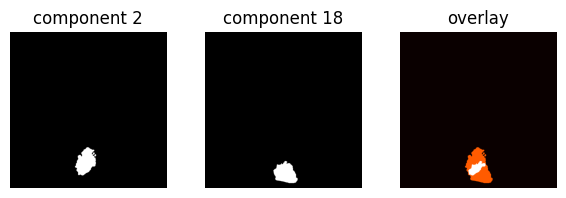

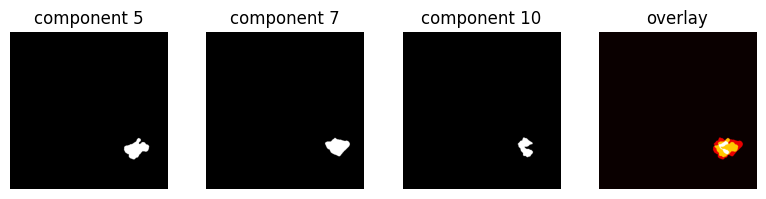

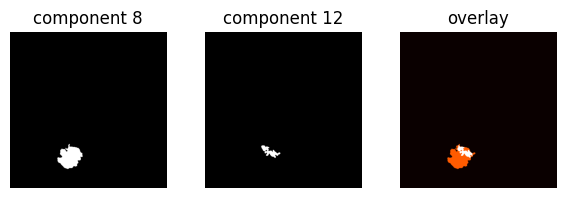

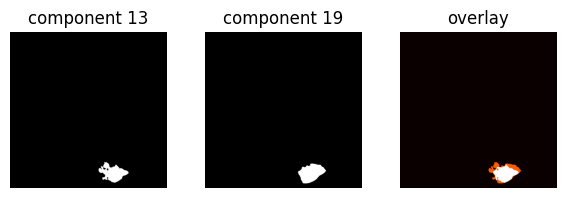

In [ ]:
path_dist = "Data"
#Read dataframe with manually selected components
temp = pd.read_excel(os.path.join(path_dist, "NMF_selected_components.xlsx"))
selcom = {
    col: temp[col].dropna().astype(int).tolist()
    for col in temp.columns
}

for folder_exp in data_source.keys():
    pups=data_source[folder_exp]
    for file_stem in pups:
        os.makedirs(os.path.join(path_dist, "NMF_analysis_results", folder_exp, file_stem), exist_ok=True)
        path_save=os.path.join(path_dist, "NMF_analysis_results", folder_exp, file_stem)
        pup = folder_exp.split("_")[0] + "_" + file_stem.split("_")[0]
        if len(selcom[pup])==0:
            print(f"No components were selected for {file_stem} from {folder_exp}")
            continue
        else:
            main(path_save, folder_exp, file_stem,selcom[pup])
        print(f"Processing {file_stem} from {folder_exp}")
